In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df=pd.read_csv("/workspaces/Aress_Task/data/shampoo_sales.csv")

In [6]:
df.head()

,Month,Sales
0,1-01,266.0
1,1-02,145.9
2,1-03,183.1
3,1-04,119.3
4,1-05,180.3


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Month   36 non-null     str    
 1   Sales   36 non-null     float64
dtypes: float64(1), str(1)
memory usage: 708.0 bytes


In [8]:
df.describe()

,Sales
count,36.000000
mean,312.600000
std,148.937164
min,119.300000
25%,192.450000
50%,280.150000
75%,411.100000
max,682.000000


In [9]:
df.isnull().sum()

Month    0
Sales    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
import seaborn as sns

<Axes: ylabel='Sales'>

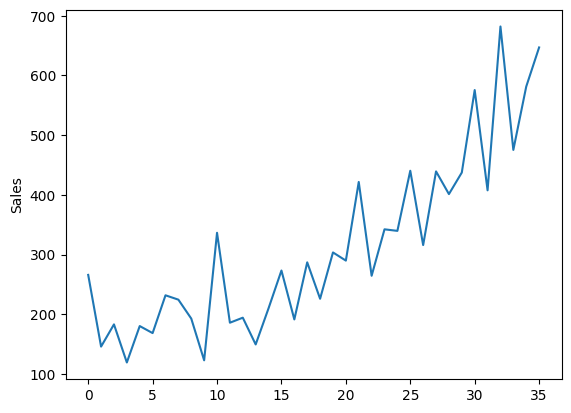

In [12]:
sns.lineplot(df['Sales'])
## Showing Upward trend

In [13]:
df[['Year', 'Month_num']] = df['Month'].str.split('-', expand=True)
# Convert to integer
df['Year'] = df['Year'].astype(int) + 2000
df['Month_num'] = df['Month_num'].astype(int)


In [14]:

# Create proper datetime column
df['Date'] = pd.to_datetime(dict(year=df['Year'],
                                 month=df['Month_num'],
                                 day=1))

# Set index
df.set_index('Date', inplace=True)

df = df.sort_index()

df.head()

,Month,Sales,Year,Month_num
Date,,,,
2001-01-01,1-01,266.0,2001,1
2001-02-01,1-02,145.9,2001,2
2001-03-01,1-03,183.1,2001,3
2001-04-01,1-04,119.3,2001,4
2001-05-01,1-05,180.3,2001,5


In [15]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 36 entries, 2001-01-01 to 2003-12-01
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Month      36 non-null     str    
 1   Sales      36 non-null     float64
 2   Year       36 non-null     int64  
 3   Month_num  36 non-null     int64  
dtypes: float64(1), int64(2), str(1)
memory usage: 1.4 KB


In [16]:
df.head()

,Month,Sales,Year,Month_num
Date,,,,
2001-01-01,1-01,266.0,2001,1
2001-02-01,1-02,145.9,2001,2
2001-03-01,1-03,183.1,2001,3
2001-04-01,1-04,119.3,2001,4
2001-05-01,1-05,180.3,2001,5


In [17]:
df['Year'].value_counts()

Year
2001    12
2002    12
2003    12
Name: count, dtype: int64

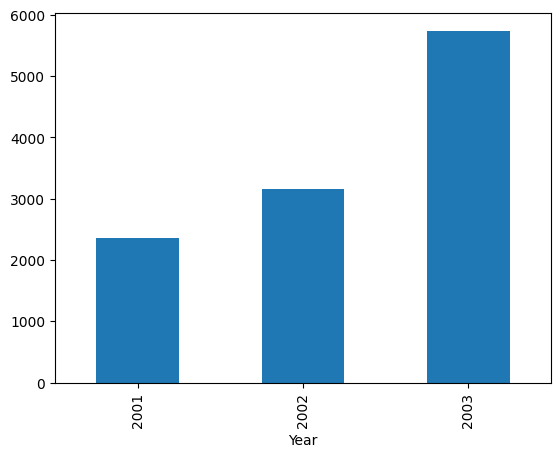

In [18]:
df.groupby('Year')['Sales'].sum().plot(
    kind='bar'
)
plt.show()

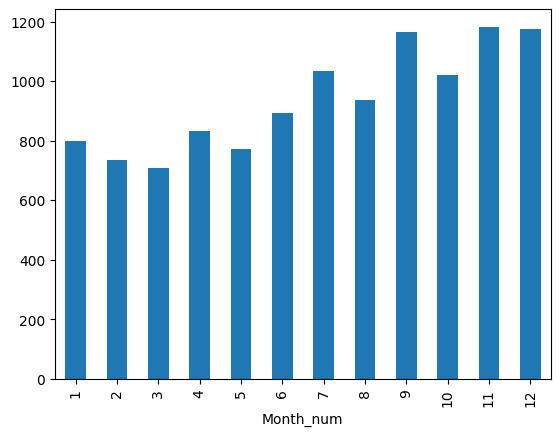

In [19]:
df.groupby('Month_num')['Sales'].sum().plot(
    kind='bar'
)
plt.show()

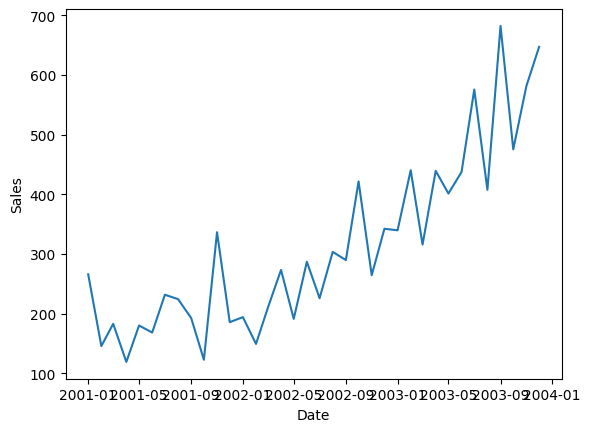

In [20]:
sns.lineplot(data=df,x=df.index,y=df['Sales'])
plt.show()

In [21]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [ ]:

ts = df['Sales']
# Check stationarity
result = adfuller(ts)

## differencing Logic 
# if result[1] > 0.05:
#    ts = ts.diff().dropna() #  differencing - d 


In [27]:
result

(np.float64(3.060142083641181),
 1.0,
 10,
 25,
 {'1%': np.float64(-3.7238633119999998),
  '5%': np.float64(-2.98648896),
  '10%': np.float64(-2.6328004)},
 np.float64(278.99726442630316))

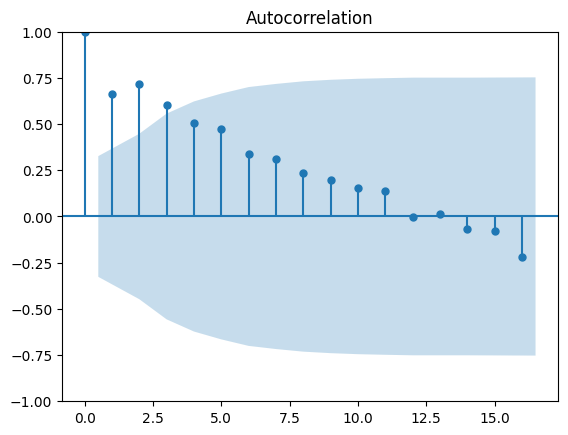

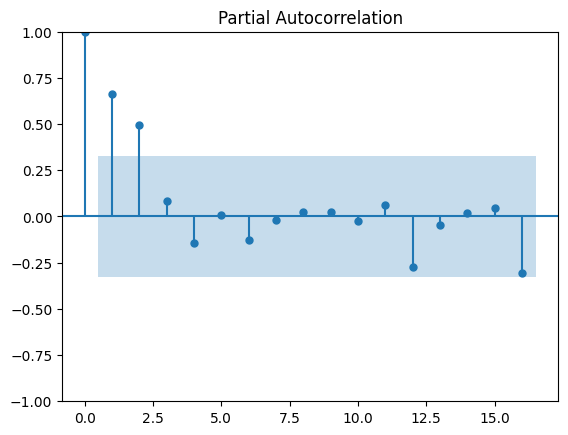

In [28]:
# Identify p and q
plot_acf(ts)
plot_pacf(ts)
plt.show()


conclusion data is not stationary

In [25]:
# Fit ARIMA model
model = ARIMA(ts, order=(1,1,1))  #p,d,q
model_fit = model.fit()

/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [26]:
# Forecast next 10 steps
forecast = model_fit.forecast(steps=12)
print(forecast)

2004-01-01    573.210555
2004-02-01    617.449903
2004-03-01    590.890877
2004-04-01    606.835548
2004-05-01    597.263189
2004-06-01    603.009940
2004-07-01    599.559887
2004-08-01    601.631121
2004-09-01    600.387659
2004-10-01    601.134170
2004-11-01    600.686003
2004-12-01    600.955059
Freq: MS, Name: predicted_mean, dtype: float64
